In [44]:
# Data Preperation

# * Check and Remove non-image files

In [45]:
def remove_non_image_file(my_data_dir):
    """
    Removes non-image files from the specified directory and counts image/non-image files.

    Args:
        my_data_dir (str): Path to the directory containing the image files.
    """

    image_extensions = ('.png', '.jpg', '.jpeg')

    # Iterate through the healthy and powdery_mildew subfolders
    for folder_name in ['healthy', 'powdery_mildew']:
        folder_path = os.path.join(my_data_dir, folder_name)
        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            image_count = 0
            non_image_count = 0
            for file in files:
                file_path = os.path.join(folder_path, file)
                if os.path.isfile(file_path):
                    if file.lower().endswith(image_extensions):
                        image_count += 1
                    else:
                        os.remove(file_path)
                        non_image_count += 1
                        print(f"Removed non-image file: {file_path}")

            # Print the counts for the current folder
            print(f"Folder: {folder_name} - has image file: {image_count}")
            print(f"Folder: {folder_name} - has non-image file: {non_image_count}")

In [46]:
import os
remove_non_image_file(my_data_dir='/workspace/Cherry-Leaves/data/cherry-leaves')

# Check for corrupted images

In [47]:
import os
from PIL import Image

# Define the dataset directory
my_data_dir = '/workspace/Cherry-Leaves/data/cherry-leaves'

# Initialize a list to store corrupted files
corrupted_files =[]

# Print a message indicating the start of the check
print("Checking for corrupted images...")

# Walk through the directory tree
for root, _, files in os.walk(my_data_dir):
    for file in files:
        # Construct the full file path
        file_path = os.path.join(root, file)
        try:
            # Attempt to open the image file
            with Image.open(file_path) as img:
                # Verify the image file
                img.verify()
        except (FileNotFoundError, OSError):
            # If an error occurs, add the file path to the list of corrupted files
            corrupted_files.append(file_path)

# Check if any corrupted files were found
if corrupted_files:
    # If corrupted files were found, print a message and list the files
    print("Corrupted files detected:")
    for file in corrupted_files:
        print(file)
else:
    # If no corrupted files were found, print a message indicating that
    print("No corrupted files found.")

# Open a file for writing the log
with open("corrupted_files_log.txt", "w") as log_file:
    # If any corrupted files were found
    if corrupted_files:
        # Write a header to the log file
        log_file.write("Corrupted files:\n")
        # Write each corrupted file path to the log file
        log_file.writelines([f"{file}\n" for file in corrupted_files])

# Print a message indicating the completion of the check and the location of the log file
print("Check completed. Results logged to corrupted_files_log.txt")

Checking for corrupted images...
No corrupted files found.
Check completed. Results logged to corrupted_files_log.txt


## Split data into train, validation and test sets

In [48]:
import os
import shutil
import random

def split_train_validation_test_images(my_data_dir, train_set_ratio, validation_set_ratio, test_set_ratio):
    """
    Split the dataset of images into train, validation, and test sets.

    Args:
        my_data_dir (str): Path to the dataset directory containing class folders.
        train_set_ratio (float): Proportion of data to be used for training.
        validation_set_ratio (float): Proportion of data to be used for validation.
        test_set_ratio (float): Proportion of data to be used for testing.

    Returns:
        None
    """
    # Check if ratios sum to 1.0
    if not abs(train_set_ratio + validation_set_ratio + test_set_ratio - 1.0) < 1e-6:
        raise ValueError("train_set_ratio, validation_set_ratio, and test_set_ratio should sum to 1.0.")

    # Get class labels (folder names)
    labels = [label for label in os.listdir(my_data_dir) if os.path.isdir(os.path.join(my_data_dir, label))]

    # Create train, validation, test directories only if they don't exist
    for folder in ['train', 'validation', 'test']:
        if not os.path.exists(os.path.join(my_data_dir, folder)):
            for label in labels:
                os.makedirs(os.path.join(my_data_dir, folder, label), exist_ok=True)

    for label in labels:
        class_dir = os.path.join(my_data_dir, label)
        files = [file for file in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, file))]
        random.shuffle(files)

        # Calculate split indices
        train_count = int(len(files) * train_set_ratio)
        val_count = int(len(files) * validation_set_ratio)
        
        train_files = files[:train_count]
        val_files = files[train_count:train_count + val_count]
        test_files = files[train_count + val_count:]

        # Move files to corresponding folders
        for file in train_files:
            shutil.move(os.path.join(class_dir, file), os.path.join(my_data_dir, 'train', label, file))

        for file in val_files:
            shutil.move(os.path.join(class_dir, file), os.path.join(my_data_dir, 'validation', label, file))

        for file in test_files:
            shutil.move(os.path.join(class_dir, file), os.path.join(my_data_dir, 'test', label, file))

        # Remove the original class folder if empty
        if not os.listdir(class_dir):
            os.rmdir(class_dir)

    print("Data successfully split into train, validation, and test sets.")

## Verify the class balance in the training set

In [49]:
import os

# Path to the training set
train_dir = "/workspace/Cherry-Leaves/data/cherry-leaves/train"

# Count and plot for training set only
train_classes = os.listdir(train_dir)
train_class_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in train_classes}

print("Training Set Class Distribution:", train_class_counts)

Training Set Class Distribution: {'healthy': 2056, 'powdery_mildew': 2049}


## Visualise Class Distribution

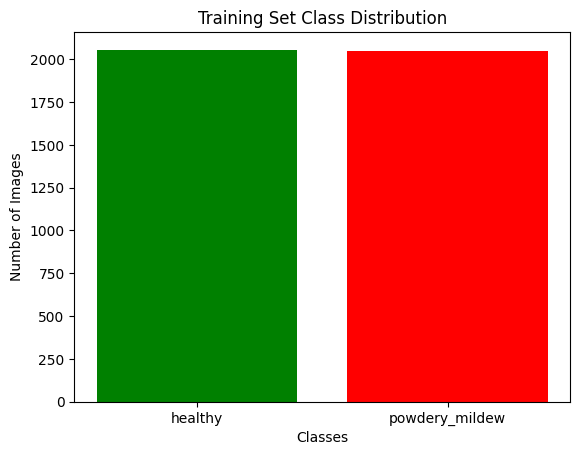

In [50]:
import matplotlib.pyplot as plt

# Filter the train_class_counts dictionary to keep only "healthy" and "powdery_mildew"
filtered_class_counts = {cls: train_class_counts[cls] for cls in train_class_counts if cls in ["healthy", "powdery_mildew"]}

# Bar chart for class distribution
plt.bar(train_class_counts.keys(), train_class_counts.values(), color=['green', 'red'])
plt.title('Training Set Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()

## Check the validation set

In [51]:
# Path to the validation set
validation_dir = "/workspace/Cherry-Leaves/data/cherry-leaves/validation"

# Count and plot for validation set
validation_classes = os.listdir(validation_dir)
validation_class_counts = {cls: len(os.listdir(os.path.join(validation_dir, cls))) for cls in validation_classes}

print("Validation Set Class Distribution:", validation_class_counts)

Validation Set Class Distribution: {'healthy': 816, 'powdery_mildew': 807}
